In [ ]:
import pandas as pd

ess = pd.read_csv("ESS11e04_1-subset.csv")
macro = pd.read_excel("ВКР датасет статс.xlsx", sheet_name="30 стран итоговых")

# убрать пробелы
macro.columns = macro.columns.str.strip()

# посмотреть колонки
print(macro.columns)

# если страна называется Country
macro = macro.rename(columns={"Country": "country"})

Index(['Country', 'Unemployment', 'GDP_growth', 'Inflation_HICP', 'Gini',
       'Unnamed: 5', 'Unnamed: 6', 'Country.1'],
      dtype='object')


In [ ]:
country_map = {
    "AL": "Albania", "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria",
    "HR": "Croatia", "CY": "Cyprus", "CZ": "Czechia", "DK": "Denmark",
    "EE": "Estonia", "FI": "Finland", "FR": "France", "DE": "Germany",
    "GR": "Greece", "HU": "Hungary", "IS": "Iceland", "IE": "Ireland",
    "IL": "Israel", "IT": "Italy", "LV": "Latvia", "LT": "Lithuania",
    "ME": "Montenegro", "NL": "Netherlands", "NO": "Norway", "PL": "Poland",
    "PT": "Portugal", "RS": "Serbia", "SK": "Slovakia", "SI": "Slovenia",
    "ES": "Spain", "SE": "Sweden", "CH": "Switzerland", "UA": "Ukraine",
    "GB": "United Kingdom"
}

ess["country"] = ess["cntry"].map(country_map)

df = ess.merge(
    macro[["country", "Unemployment", "GDP_growth", "Inflation_HICP", "Gini"]],
    on="country",
    how="left"
)

df.to_csv("merged_dataset.csv", index=False)

In [ ]:
df

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,impenva,imptrada,prob,stratum,psu,country,Unemployment,GDP_growth,Inflation_HICP,Gini
0,ESS11e04_1,11,4.1,12.01.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,2,3,0.000579,107,317,Austria,"4,8","4,2","8,6","27,8"
1,ESS11e04_1,11,4.1,12.01.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,1,4,0.001124,69,128,Austria,"4,8","4,2","8,6","27,8"
2,ESS11e04_1,11,4.1,12.01.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,1,3,0.000493,18,418,Austria,"4,8","4,2","8,6","27,8"
3,ESS11e04_1,11,4.1,12.01.2026,50106,AT,0.556061,0.176228,0.330915,0.058316,...,2,2,0.001233,101,295,Austria,"4,8","4,2","8,6","27,8"
4,ESS11e04_1,11,4.1,12.01.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,2,2,0.000949,115,344,Austria,"4,8","4,2","8,6","27,8"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44860,ESS11e04_1,11,4.1,12.01.2026,86379,SK,1.758655,3.777879,0.315904,1.193448,...,2,1,0.000432,1453,24812,Slovakia,"6,1","0,2","12,1","21,2"
44861,ESS11e04_1,11,4.1,12.01.2026,86407,SK,1.302318,0.698084,0.315904,0.220528,...,2,3,0.000583,1470,25026,Slovakia,"6,1","0,2","12,1","21,2"
44862,ESS11e04_1,11,4.1,12.01.2026,86408,SK,1.262293,3.717124,0.315904,1.174255,...,2,4,0.000602,1474,25058,Slovakia,"6,1","0,2","12,1","21,2"
44863,ESS11e04_1,11,4.1,12.01.2026,86426,SK,4.000705,4.000297,0.315904,1.263711,...,2,1,0.000184,1474,25061,Slovakia,"6,1","0,2","12,1","21,2"


In [ ]:
print(df.columns)

Index(['name', 'essround', 'edition', 'proddate', 'idno', 'cntry', 'dweight',
       'pspwght', 'pweight', 'anweight', 'psppsgva', 'psppipla', 'trstprl',
       'trstlgl', 'trstplc', 'trstplt', 'trstprt', 'lrscale', 'stfeco',
       'stfdem', 'stfedu', 'stfhlth', 'gincdif', 'freehms', 'gndr', 'agea',
       'maritalb', 'eduyrs', 'uempla', 'hincfel', 'ipeqopta', 'ipfrulea',
       'ipudrsta', 'impfreea', 'ipstrgva', 'ipbhprpa', 'impenva', 'imptrada',
       'prob', 'stratum', 'psu', 'country', 'Unemployment', 'GDP_growth',
       'Inflation_HICP', 'Gini'],
      dtype='object')


In [ ]:
cols_to_drop = [
    "name",
    "edition",
    "proddate",
    "prob",
    "stratum",
    "psu",
    "cntry"
]

df = df.drop(columns=cols_to_drop)

In [ ]:
df

,essround,idno,dweight,pspwght,pweight,anweight,psppsgva,psppipla,trstprl,trstlgl,...,impfreea,ipstrgva,ipbhprpa,impenva,imptrada,country,Unemployment,GDP_growth,Inflation_HICP,Gini
0,11,50014,1.185115,0.392891,0.330915,0.130013,4,4,6,9,...,2,2,2,2,3,Austria,"4,8","4,2","8,6","27,8"
1,11,50030,0.609898,0.325153,0.330915,0.107598,3,3,6,6,...,2,2,2,1,4,Austria,"4,8","4,2","8,6","27,8"
2,11,50057,1.392330,4.000023,0.330915,1.323666,4,4,7,5,...,2,2,3,1,3,Austria,"4,8","4,2","8,6","27,8"
3,11,50106,0.556061,0.176228,0.330915,0.058316,2,2,5,6,...,2,3,3,2,2,Austria,"4,8","4,2","8,6","27,8"
4,11,50145,0.722795,1.060940,0.330915,0.351080,3,4,6,8,...,2,2,2,2,2,Austria,"4,8","4,2","8,6","27,8"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44860,11,86379,1.758655,3.777879,0.315904,1.193448,4,4,4,5,...,4,2,3,2,1,Slovakia,"6,1","0,2","12,1","21,2"
44861,11,86407,1.302318,0.698084,0.315904,0.220528,3,3,4,7,...,2,4,2,2,3,Slovakia,"6,1","0,2","12,1","21,2"
44862,11,86408,1.262293,3.717124,0.315904,1.174255,4,3,5,4,...,1,1,3,2,4,Slovakia,"6,1","0,2","12,1","21,2"
44863,11,86426,4.000705,4.000297,0.315904,1.263711,8,1,0,5,...,3,1,3,2,1,Slovakia,"6,1","0,2","12,1","21,2"


In [ ]:
df.to_csv("ess_eurostat_merged_dataset.csv", index=False)

In [ ]:
print(df.columns)

Index(['essround', 'idno', 'dweight', 'pspwght', 'pweight', 'anweight',
       'psppsgva', 'psppipla', 'trstprl', 'trstlgl', 'trstplc', 'trstplt',
       'trstprt', 'lrscale', 'stfeco', 'stfdem', 'stfedu', 'stfhlth',
       'gincdif', 'freehms', 'gndr', 'agea', 'maritalb', 'eduyrs', 'uempla',
       'hincfel', 'ipeqopta', 'ipfrulea', 'ipudrsta', 'impfreea', 'ipstrgva',
       'ipbhprpa', 'impenva', 'imptrada', 'country', 'Unemployment',
       'GDP_growth', 'Inflation_HICP', 'Gini'],
      dtype='object')


###EDA

In [ ]:
import pandas as pd

df = pd.read_csv("ess_eurostat_merged_dataset.csv.csv")

In [ ]:
df

,essround,idno,dweight,pspwght,pweight,anweight,psppsgva,psppipla,trstprl,trstlgl,...,impfreea,ipstrgva,ipbhprpa,impenva,imptrada,country,Unemployment,GDP_growth,Inflation_HICP,Gini
0,11,50014,1.185115,0.392891,0.330915,0.130013,4,4,6,9,...,2,2,2,2,3,Austria,"4,8","4,2","8,6","27,8"
1,11,50030,0.609898,0.325153,0.330915,0.107598,3,3,6,6,...,2,2,2,1,4,Austria,"4,8","4,2","8,6","27,8"
2,11,50057,1.392330,4.000023,0.330915,1.323666,4,4,7,5,...,2,2,3,1,3,Austria,"4,8","4,2","8,6","27,8"
3,11,50106,0.556061,0.176228,0.330915,0.058316,2,2,5,6,...,2,3,3,2,2,Austria,"4,8","4,2","8,6","27,8"
4,11,50145,0.722795,1.060940,0.330915,0.351080,3,4,6,8,...,2,2,2,2,2,Austria,"4,8","4,2","8,6","27,8"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44860,11,86379,1.758655,3.777879,0.315904,1.193448,4,4,4,5,...,4,2,3,2,1,Slovakia,"6,1","0,2","12,1","21,2"
44861,11,86407,1.302318,0.698084,0.315904,0.220528,3,3,4,7,...,2,4,2,2,3,Slovakia,"6,1","0,2","12,1","21,2"
44862,11,86408,1.262293,3.717124,0.315904,1.174255,4,3,5,4,...,1,1,3,2,4,Slovakia,"6,1","0,2","12,1","21,2"
44863,11,86426,4.000705,4.000297,0.315904,1.263711,8,1,0,5,...,3,1,3,2,1,Slovakia,"6,1","0,2","12,1","21,2"


In [ ]:
df.shape

(44865, 39)

In [ ]:
df['country'].nunique()

27

In [ ]:
df['country'].value_counts()

,count
country,
Italy,2865
Greece,2757
Germany,2420
Austria,2354
Bulgaria,2239
Hungary,2118
Ireland,2017
Spain,1844
France,1771


In [ ]:
df = df.replace({77: None, 88: None, 99: None})

In [ ]:
df.isna().mean().sort_values(ascending=False)

,0
lrscale,0.131729
stfedu,0.041101
stfdem,0.030937
trstlgl,0.020617
trstprl,0.019213
trstprt,0.017497
ipfrulea,0.016405
stfeco,0.016360
gap,0.016360
stfeco_z,0.016360


,stfeco
country,
Bulgaria,3.041894
Greece,3.366959
Cyprus,3.58284
France,3.647879
Slovakia,3.665245
Latvia,3.688725
Croatia,3.696689
Portugal,3.75037
Estonia,3.87011


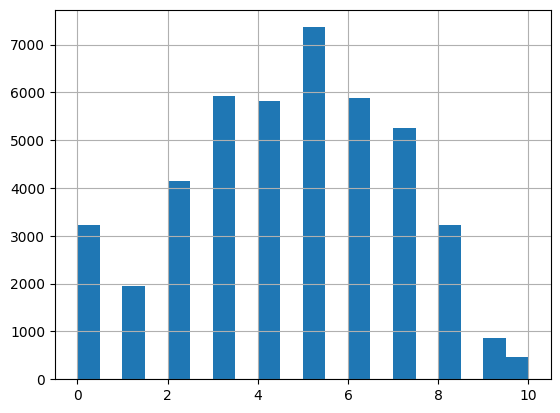

In [ ]:
df['stfeco'].hist(bins=20)
df.groupby('country')['stfeco'].mean().sort_values()

Доверие к институтам (H1, H2)

,trstprl,trstlgl,trstplt,stfeco
trstprl,1.000000,0.656644,0.749459,0.519279
trstlgl,0.656644,1.000000,0.593674,0.425578
trstplt,0.749459,0.593674,1.000000,0.507036
stfeco,0.519279,0.425578,0.507036,1.000000


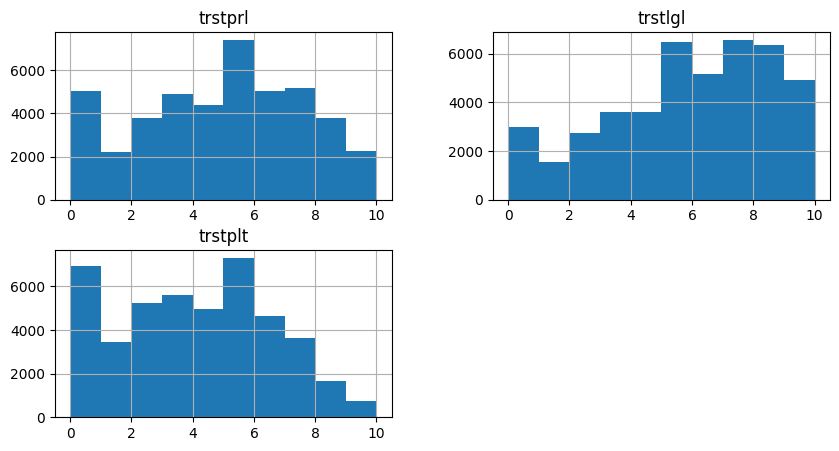

In [ ]:
trust_cols = ['trstprl', 'trstlgl', 'trstplt']

df[trust_cols] = df[trust_cols].apply(pd.to_numeric, errors='coerce')

df[trust_cols].hist(figsize=(10,5))
df[trust_cols + ['stfeco']].corr()

Демократия и госкачество (H2)

In [ ]:
demo_cols = ['stfdem', 'stfedu', 'stfhlth']
df[demo_cols + ['stfeco']].corr()

,stfdem,stfedu,stfhlth,stfeco
stfdem,1.000000,0.512527,0.476320,0.598844
stfedu,0.512527,1.000000,0.559359,0.463771
stfhlth,0.476320,0.559359,1.000000,0.471482
stfeco,0.598844,0.463771,0.471482,1.000000


Объективная экономика vs субъективная (H3)

In [ ]:
macro_cols = ['GDP_growth', 'Unemployment', 'Inflation_HICP', 'Gini']

for col in macro_cols:
    df[col] = df[col].astype(str).str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[macro_cols + ['stfeco']].corr()

,GDP_growth,Unemployment,Inflation_HICP,Gini,stfeco
GDP_growth,1.000000,0.443762,-0.177710,0.224367,-0.104256
Unemployment,0.443762,1.000000,-0.042151,0.325455,-0.156323
Inflation_HICP,-0.177710,-0.042151,1.000000,0.270931,-0.136887
Gini,0.224367,0.325455,0.270931,1.000000,-0.175986
stfeco,-0.104256,-0.156323,-0.136887,-0.175986,1.000000


создать переменную расхождения

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['stfeco_z'] = scaler.fit_transform(df[['stfeco']])
df['gdp_z'] = scaler.fit_transform(df[['GDP_growth']])

df['gap'] = df['stfeco_z'] - df['gdp_z']

,gap
country,
Croatia,-2.088305
Montenegro,-1.937774
Greece,-1.482605
Cyprus,-1.479299
Portugal,-1.452557
Iceland,-1.077908
Bulgaria,-1.050124
Spain,-0.775831
Serbia,-0.760848


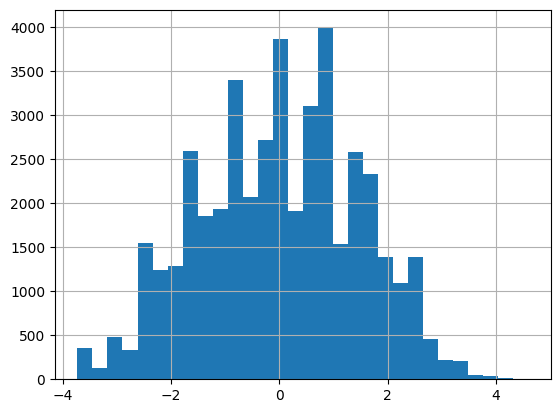

In [ ]:
df['gap'].hist(bins=30)

df.groupby('country')['gap'].mean().sort_values()

Ценности и идеология (H4)

In [ ]:
values_cols = ['gincdif', 'freehms', 'lrscale']

df[values_cols + ['stfeco']].corr()

,gincdif,freehms,lrscale,stfeco
gincdif,1.000000,0.060238,0.147871,0.144260
freehms,0.060238,1.000000,0.092168,-0.102216
lrscale,0.147871,0.092168,1.000000,0.110399
stfeco,0.144260,-0.102216,0.110399,1.000000


In [ ]:
values_cols = ['gincdif', 'freehms', 'lrscale']

df[values_cols] = df[values_cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df[values_cols].dtypes
df['lrscale'].isna().mean()
sorted(df['lrscale'].dropna().unique())[:15]

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(7.0),
 np.float64(8.0),
 np.float64(9.0),
 np.float64(10.0)]

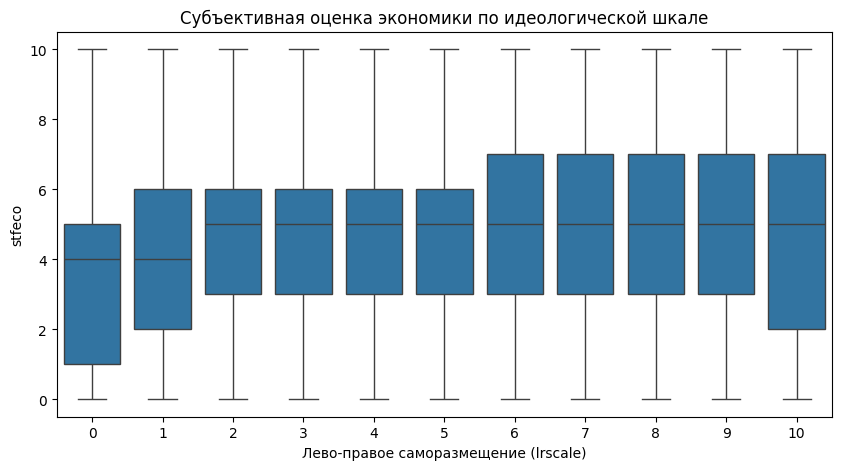

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tmp = df[['lrscale', 'stfeco']].dropna().copy()
tmp['lrscale'] = tmp['lrscale'].astype(int)

plt.figure(figsize=(10, 5))
sns.boxplot(data=tmp, x='lrscale', y='stfeco')
plt.title('Субъективная оценка экономики по идеологической шкале')
plt.xlabel('Лево-правое саморазмещение (lrscale)')
plt.ylabel('stfeco')
plt.show()

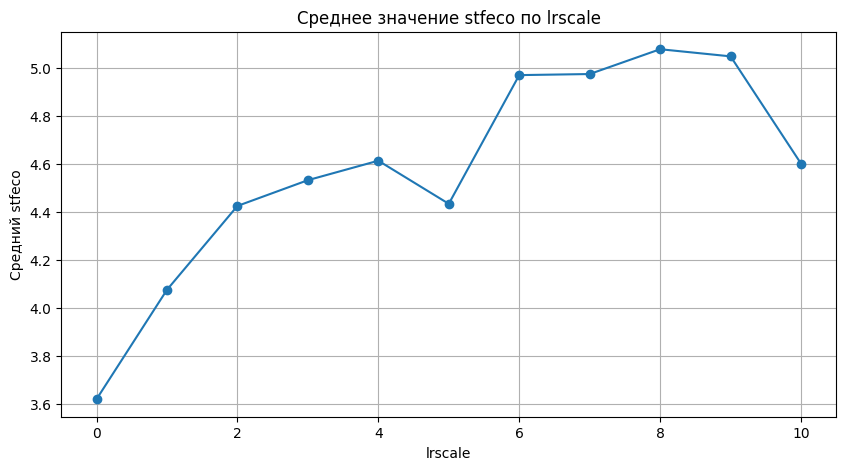

In [ ]:
tmp.groupby('lrscale')['stfeco'].mean().plot(marker='o', figsize=(10,5))
plt.title('Среднее значение stfeco по lrscale')
plt.xlabel('lrscale')
plt.ylabel('Средний stfeco')
plt.grid(True)
plt.show()

Соцдем (H5)

In [ ]:
soc_cols = ['agea', 'eduyrs', 'hincfel', 'uempla']

df[soc_cols + ['stfeco']].corr()

,agea,eduyrs,hincfel,uempla,stfeco
agea,1.000000,-0.051285,0.071293,-0.018069,-0.008903
eduyrs,-0.051285,1.000000,-0.224807,-0.011306,0.091791
hincfel,0.071293,-0.224807,1.000000,0.115717,-0.236133
uempla,-0.018069,-0.011306,0.115717,1.000000,-0.044367
stfeco,-0.008903,0.091791,-0.236133,-0.044367,1.000000


Межстрановые различия (H6)

<Axes: xlabel='country'>

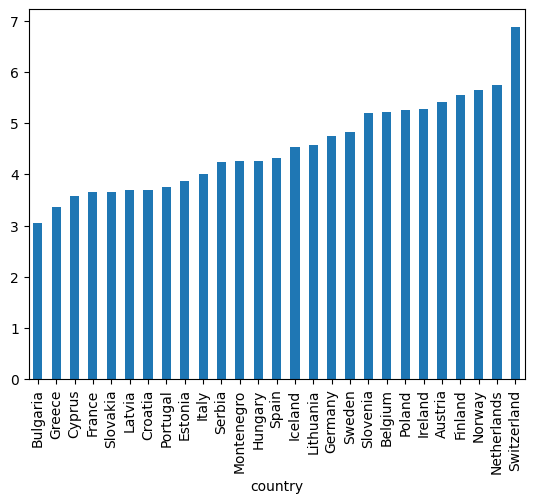

In [ ]:
df.groupby('country')['stfeco'].mean().sort_values().plot(kind='bar')

Проверка распределений (для моделей)

<Axes: xlabel='stfeco'>

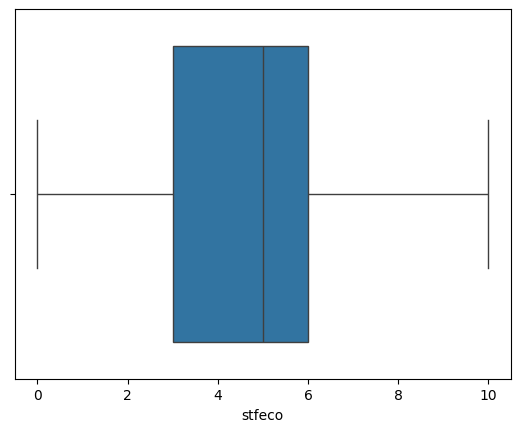

In [ ]:
sns.boxplot(x=df['stfeco'])

In [ ]:
df.to_csv('df_after_EDA.csv', index=False)

**Спецификация модели**

In [ ]:
import pandas as pd

df = pd.read_csv("df_after_EDA.csv")

In [ ]:
df

,essround,idno,dweight,pspwght,pweight,anweight,psppsgva,psppipla,trstprl,trstlgl,...,impenva,imptrada,country,Unemployment,GDP_growth,Inflation_HICP,Gini,stfeco_z,gdp_z,gap
0,11,50014,1.185115,0.392891,0.330915,0.130013,4,4,6.0,9.0,...,2.0,3.0,Austria,4.8,4.2,8.6,27.8,0.633006,0.174834,0.458171
1,11,50030,0.609898,0.325153,0.330915,0.107598,3,3,6.0,6.0,...,1.0,4.0,Austria,4.8,4.2,8.6,27.8,-1.051206,0.174834,-1.226040
2,11,50057,1.392330,4.000023,0.330915,1.323666,4,4,7.0,5.0,...,1.0,3.0,Austria,4.8,4.2,8.6,27.8,0.633006,0.174834,0.458171
3,11,50106,0.556061,0.176228,0.330915,0.058316,2,2,5.0,6.0,...,2.0,2.0,Austria,4.8,4.2,8.6,27.8,-0.209100,0.174834,-0.383934
4,11,50145,0.722795,1.060940,0.330915,0.351080,3,4,6.0,8.0,...,2.0,2.0,Austria,4.8,4.2,8.6,27.8,0.633006,0.174834,0.458171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44860,11,86379,1.758655,3.777879,0.315904,1.193448,4,4,4.0,5.0,...,2.0,1.0,Slovakia,6.1,0.2,12.1,21.2,-0.630153,-1.577012,0.946859
44861,11,86407,1.302318,0.698084,0.315904,0.220528,3,3,4.0,7.0,...,2.0,3.0,Slovakia,6.1,0.2,12.1,21.2,0.633006,-1.577012,2.210017
44862,11,86408,1.262293,3.717124,0.315904,1.174255,4,3,5.0,4.0,...,2.0,4.0,Slovakia,6.1,0.2,12.1,21.2,0.633006,-1.577012,2.210017
44863,11,86426,4.000705,4.000297,0.315904,1.263711,8,1,0.0,5.0,...,2.0,1.0,Slovakia,6.1,0.2,12.1,21.2,0.211953,-1.577012,1.788964


In [ ]:
# ============================================================
# ВКР: baseline + 5 моделей + метрики
# Версия с ПРИНУДИТЕЛЬНЫМ приведением типов к numeric
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf


# ============================================================
# 1. ЗАДАЁМ ПЕРЕМЕННЫЕ
# ============================================================
target = 'stfeco'

trust_cols = ['trstprl', 'trstlgl', 'trstplt']
demo_service_vars = ['stfdem', 'stfedu', 'stfhlth']
macro_cols = ['Unemployment', 'GDP_growth', 'Inflation_HICP', 'Gini']
socio_demo_vars = ['agea', 'eduyrs', 'hincfel', 'uempla']
ideology_var = 'lrscale'
country_var = 'country'

all_numeric_cols = [target] + trust_cols + demo_service_vars + macro_cols + socio_demo_vars + [ideology_var]

# Проверка наличия колонок
all_needed = all_numeric_cols + [country_var]
missing_cols = [col for col in all_needed if col not in df.columns]
if missing_cols:
    raise ValueError(f"Не найдены колонки: {missing_cols}")


# ============================================================
# 2. СОЗДАЁМ РАБОЧУЮ КОПИЮ
# ============================================================
work_df = df[all_needed].copy()


# ============================================================
# 3. ПРИВОДИМ ВСЕ ЧИСЛОВЫЕ ПЕРЕМЕННЫЕ К NUMERIC
# ============================================================
# Это ключевой фикс:
# если где-то строки, object, категории и т.д.,
# они будут переведены в числа
for col in all_numeric_cols:
    work_df[col] = pd.to_numeric(work_df[col], errors='coerce')

# country оставляем как категориальную переменную
work_df[country_var] = work_df[country_var].astype(str)


# ============================================================
# 4. УДАЛЯЕМ ПРОПУСКИ ПО НУЖНЫМ ПОЛЯМ
# ============================================================
work_df = work_df.dropna().copy()

print("Размер итогового датафрейма после dropna:", work_df.shape)
print("\nТипы данных:")
print(work_df.dtypes)


# ============================================================
# 5. СОЗДАЁМ trust_index
# ============================================================
work_df['trust_index'] = work_df[trust_cols].mean(axis=1)


# ============================================================
# 6. СОЗДАЁМ macro_index
# ============================================================
macro_temp = work_df[macro_cols].copy()

# Разворачиваем GDP_growth:
# высокий рост = лучше, поэтому ставим минус,
# чтобы высокий macro_index = хуже макроусловия
macro_temp['GDP_growth'] = -macro_temp['GDP_growth']

scaler = StandardScaler()
macro_scaled = pd.DataFrame(
    scaler.fit_transform(macro_temp),
    columns=macro_cols,
    index=work_df.index
)

work_df['macro_index'] = macro_scaled.mean(axis=1)


# ============================================================
# 7. ОСТАВЛЯЕМ ТОЛЬКО ИТОГОВЫЕ ПЕРЕМЕННЫЕ ДЛЯ МОДЕЛЕЙ
# ============================================================
final_cols = [
    target,
    'trust_index',
    'macro_index',
    ideology_var,
    country_var
] + demo_service_vars + socio_demo_vars

work_df = work_df[final_cols].dropna().copy()

print("\nРазмер после создания индексов:", work_df.shape)
print("\nПроверка target:")
print("dtype:", work_df[target].dtype)
print("уникальные значения stfeco:", sorted(work_df[target].dropna().unique())[:20])


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================
train_df, test_df = train_test_split(
    work_df,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", train_df.shape)
print("Test shape: ", test_df.shape)


# ============================================================
# 9. ФУНКЦИЯ ДЛЯ МЕТРИК
# ============================================================
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# ============================================================
# 10. ФОРМУЛЫ 5 МОДЕЛЕЙ
# ============================================================
formula_model_1 = f"{target} ~ trust_index"

formula_model_2 = (
    f"{target} ~ trust_index + " + " + ".join(demo_service_vars)
)

formula_model_3 = (
    f"{target} ~ trust_index + "
    + " + ".join(demo_service_vars)
    + " + macro_index"
)

formula_model_4 = (
    f"{target} ~ trust_index + "
    + " + ".join(demo_service_vars)
    + " + macro_index"
    + " + " + " + ".join(socio_demo_vars)
)

formula_model_5 = (
    f"{target} ~ trust_index * {ideology_var} + "
    + " + ".join(demo_service_vars)
    + " + macro_index"
    + " + " + " + ".join(socio_demo_vars)
    + f" + C({country_var})"
)

models = {
    "Model 1: trust only": formula_model_1,
    "Model 2: + democracy/services": formula_model_2,
    "Model 3: + macro": formula_model_3,
    "Model 4: + socio-demo": formula_model_4,
    "Model 5: interaction + country FE": formula_model_5
}


# ============================================================
# 11. BASELINE
# ============================================================
results = []
fitted_models = {}

y_train = train_df[target]
y_test = test_df[target]

baseline_pred = np.repeat(y_train.mean(), len(y_test))
baseline_mae, baseline_rmse, baseline_r2 = get_metrics(y_test, baseline_pred)

results.append({
    "model": "Baseline: mean",
    "formula": "predict mean(stfeco) from train",
    "n_train": len(train_df),
    "n_test": len(test_df),
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2,
    "Adj_R2_train": np.nan,
    "AIC_train": np.nan,
    "BIC_train": np.nan
})


# ============================================================
# 12. ОБУЧАЕМ 5 МОДЕЛЕЙ
# ============================================================
for model_name, formula in models.items():
    print("\n----------------------------------------")
    print("Строим:", model_name)
    print("Формула:", formula)

    model = smf.ols(formula=formula, data=train_df).fit()
    fitted_models[model_name] = model

    pred_test = model.predict(test_df)
    mae, rmse, r2 = get_metrics(y_test, pred_test)

    results.append({
        "model": model_name,
        "formula": formula,
        "n_train": int(model.nobs),
        "n_test": len(test_df),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2_train": model.rsquared_adj,
        "AIC_train": model.aic,
        "BIC_train": model.bic
    })


# ============================================================
# 13. ИТОГОВАЯ ТАБЛИЦА
# ============================================================
results_df = pd.DataFrame(results)

metric_cols = ["MAE", "RMSE", "R2", "Adj_R2_train", "AIC_train", "BIC_train"]
results_df[metric_cols] = results_df[metric_cols].round(4)

print("\n========================================")
print("ИТОГОВЫЕ МЕТРИКИ")
print("========================================")
display(results_df)

print("\nЧтобы посмотреть коэффициенты модели:")
print('fitted_models["Model 1: trust only"].summary()')
print('fitted_models["Model 5: interaction + country FE"].summary()')

Размер итогового датафрейма после dropna: (35390, 17)

Типы данных:
stfeco            float64
trstprl           float64
trstlgl           float64
trstplt           float64
stfdem            float64
stfedu            float64
stfhlth           float64
Unemployment      float64
GDP_growth        float64
Inflation_HICP    float64
Gini              float64
agea              float64
eduyrs            float64
hincfel             int64
uempla              int64
lrscale           float64
country            object
dtype: object

Размер после создания индексов: (35390, 12)

Проверка target:
dtype: float64
уникальные значения stfeco: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]

Train shape: (28312, 12)
Test shape:  (7078, 12)

----------------------------------------
Строим: Model 1: trust only
Формула: stfeco ~ trust_index

------------------------------

,model,formula,n_train,n_test,MAE,RMSE,R2,Adj_R2_train,AIC_train,BIC_train
0,Baseline: mean,predict mean(stfeco) from train,28312,7078,1.9140,2.3143,-0.0001,NaN,NaN,NaN
1,Model 1: trust only,stfeco ~ trust_index,28312,7078,1.5429,1.9258,0.3075,0.2831,118773.9878,118790.4899
2,Model 2: + democracy/services,stfeco ~ trust_index + stfdem + stfedu + stfhlth,28312,7078,1.3714,1.7542,0.4254,0.4196,112796.8349,112838.0901
3,Model 3: + macro,stfeco ~ trust_index + stfdem + stfedu + stfhl...,28312,7078,1.3673,1.7498,0.4283,0.4215,112704.5445,112754.0507
4,Model 4: + socio-demo,stfeco ~ trust_index + stfdem + stfedu + stfhl...,28312,7078,1.3612,1.7427,0.4329,0.4279,112392.7931,112475.3035
5,Model 5: interaction + country FE,stfeco ~ trust_index * lrscale + stfdem + stfe...,28312,7078,1.3144,1.6873,0.4684,0.4667,110431.8854,110737.1739



Чтобы посмотреть коэффициенты модели:
fitted_models["Model 1: trust only"].summary()
fitted_models["Model 5: interaction + country FE"].summary()


In [ ]:
fitted_models["Model 5: interaction + country FE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 stfeco   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     689.2
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:05:21   Log-Likelihood:                -55179.
No. Observations:               28312   AIC:                         1.104e+05
Df Residuals:                   28275   BIC:                         1.107e+05
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     1.3262      0.081     16.379      0.000       1.167       1.485
C(country)[T.Belgium]         0.0060      0.065      0.092      0.927      -0.122       0.134
C(country)[T.Bulgaria]       -0.2046      0.049     -4.187      0.000      -0.300      -0.109
C(country)[T.Croatia]        -0.6002      0.071     -8.464      0.000      -0.739      -0.461
C(country)[T.Cyprus]         -0.8874      0.095     -9.344      0.000      -1.074      -0.701
C(country)[T.Estonia]        -0.6998      0.055    -12.620      0.000      -0.808      -0.591
C(country)[T.Finland]        -0.4639      0.060     -7.751      0.000      -0.581      -0.347
C(country)[T.France]         -0.7839      0.059    -13.209      0.000      -0.900      -0.668
C(country)[T.Germany]        -0.2015      0.054     -3.743      0.000      -0.307      -0.096
C(country)[T.Greece]         -0.2096      0.047     -4.460      0.000      -0.302      -0.117
C(country)[T.Hungary]         0.1223      0.060      2.045      0.041       0.005       0.240
C(country)[T.Iceland]        -1.2091      0.098    -12.310      0.000      -1.402      -1.017
C(country)[T.Ireland]         0.0727      0.073      1.003      0.316      -0.069       0.215
C(country)[T.Italy]          -0.4541      0.051     -8.947      0.000      -0.554      -0.355
C(country)[T.Latvia]          0.2075      0.067      3.119      0.002       0.077       0.338
C(country)[T.Lithuania]       0.6874      0.056     12.188      0.000       0.577       0.798
C(country)[T.Montenegro]      0.4472      0.057      7.833      0.000       0.335       0.559
C(country)[T.Netherlands]     0.1426      0.065      2.180      0.029       0.014       0.271
C(country)[T.Norway]         -0.7303      0.072    -10.132      0.000      -0.872      -0.589
C(country)[T.Poland]          0.8819      0.068     12.900      0.000       0.748       1.016
C(country)[T.Portugal]       -0.3715      0.074     -5.048      0.000      -0.516      -0.227
C(country)[T.Serbia]          0.2628      0.064      4.110      0.000       0.137       0.388
C(country)[T.Slovakia]       -0.4333      0.065     -6.652      0.000      -0.561      -0.306
C(country)[T.Slovenia]        0.5348      0.080      6.713      0.000       0.379       0.691
C(country)[T.Spain]          -0.1385      0.051     -2.722      0.006      -0.238      -0.039
C(country)[T.Sweden]         -0.6911      0.062    -11.080      0.000      -0.813      -0.569
C(country)[T.Switzerland]     0.5789      0.074      7.788      0.000       0.433       0.725
trust_index                   0.1821      0.012     15.678      0.000       0.159       0.205
lrscale                       0.0182      0.010      1.875      0.061      -0.001       0.037
trust_index:lrscale           0.0048      0.002      2.553      0.011      

LightGBM / XGBoost и SHAP

In [ ]:
!pip install lightgbm shap

In [ ]:
print("NaN in target:", df["stfeco_z"].isna().sum())

print("Any inf in df:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())

print("NaN by columns:")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

NaN in target: 734
Any inf in df: 0
NaN by columns:
lrscale     5910
stfedu      1844
stfdem      1388
trstlgl      925
trstprl      862
trstprt      785
ipfrulea     736
gap          734
stfeco_z     734
stfeco       734
ipstrgva     715
maritalb     711
eduyrs       688
trstplt      649
agea         647
ipbhprpa     549
ipudrsta     540
ipeqopta     463
impenva      419
imptrada     415
trstplc      414
impfreea     411
stfhlth      343
dtype: int64


LightGBM модель

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer

from lightgbm import LGBMRegressor
import shap
import matplotlib.pyplot as plt

# =========================
# 1. Загружаем данные
# =========================
df = pd.read_csv("df_after_EDA.csv")

# заменяем inf на NaN на всякий случай
df = df.replace([np.inf, -np.inf], np.nan)

# =========================
# 2. Задаем target
# =========================
target = "stfeco_z"

# колонки, которые лучше убрать
drop_cols = ["idno"]  # можно добавить essround, если не хочешь его использовать

# удаляем строки, где нет target
df = df.dropna(subset=[target]).copy()

# =========================
# 3. Делим на X и y
# =========================
X = df.drop(columns=[target, "idno", "stfeco", "gap"], errors="ignore")
y = df[target]

# если есть строковые признаки, найдём их
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Числовые признаки:", len(num_cols))
print("Категориальные признаки:", len(cat_cols))
print("Размер данных:", X.shape)

# =========================
# 4. Train / test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. Imputation
# =========================
# числовые -> медиана
num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# категориальные -> самая частая категория
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

    for col in cat_cols:
        X_train[col] = X_train[col].astype("category")
        X_test[col] = X_test[col].astype("category")

# =========================
# 6. LightGBM
# =========================
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# предсказания
y_pred_lgbm = lgbm_model.predict(X_test)

# метрики
r2_lgbm = r2_score(y_test, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

print("LightGBM results:")
print("R2   =", round(r2_lgbm, 4))
print("MAE  =", round(mae_lgbm, 4))
print("RMSE =", round(rmse_lgbm, 4))

Числовые признаки: 37
Категориальные признаки: 1
Размер данных: (44131, 38)
LightGBM results:
R2   = 0.5204
MAE  = 0.5356
RMSE = 0.6944


(опционально) XGBoost

In [2]:
from xgboost import XGBRegressor

# для XGBoost лучше перевести category в коды
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype("category").cat.codes
    X_test_xgb[col] = X_test_xgb[col].astype("category").cat.codes

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb = xgb_model.predict(X_test_xgb)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost results:")
print("R2   =", round(r2_xgb, 4))
print("MAE  =", round(mae_xgb, 4))
print("RMSE =", round(rmse_xgb, 4))

XGBoost results:
R2   = 0.5146
MAE  = 0.5383
RMSE = 0.6986


SHAP для LightGBM

In [3]:
import shap

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)

Summary plot

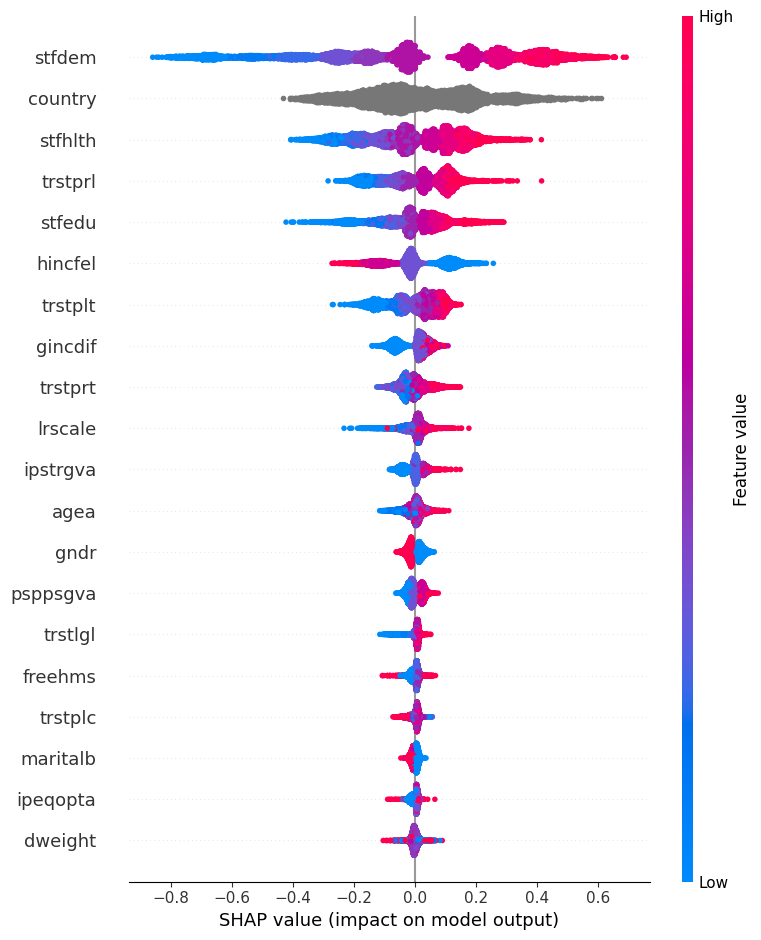

In [4]:
shap.summary_plot(shap_values, X_test)

Bar plot важности признаков

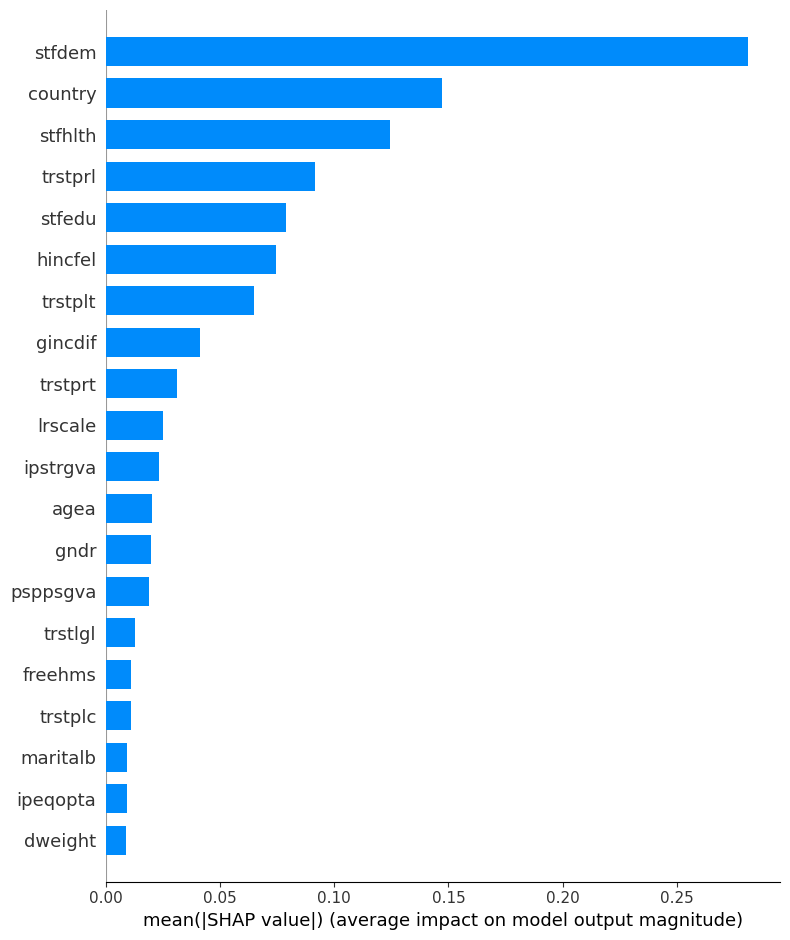

In [5]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

Топ признаков таблицей

In [6]:
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

importance_df.head(15)

,feature,mean_abs_shap
13,stfdem,0.281240
32,country,0.147295
15,stfhlth,0.124548
7,trstprl,0.091541
14,stfedu,0.078899
23,hincfel,0.074283
10,trstplt,0.064895
16,gincdif,0.041116
11,trstprt,0.031033
12,lrscale,0.025117


Dependence plot по доверию

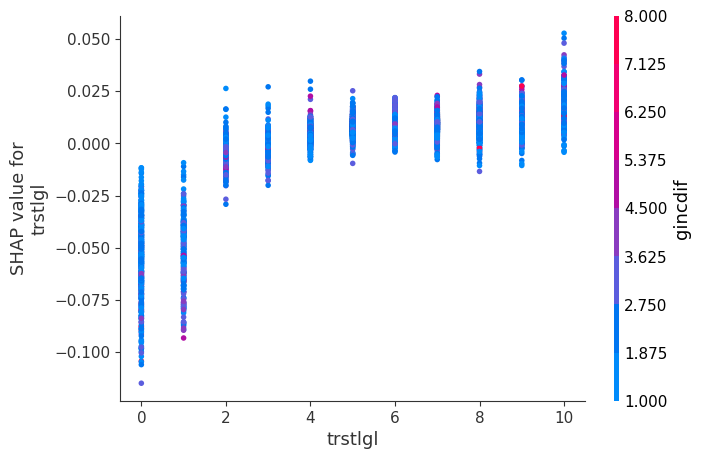

In [7]:
shap.dependence_plot("trstlgl", shap_values, X_test)

In [9]:
import pandas as pd

df_plot = pd.DataFrame({
    "trust": X_test["trstlgl"],
    "shap": shap_values[:, list(X_test.columns).index("trstlgl")]
})

df_plot.groupby("trust")["shap"].mean()

,shap
trust,
0.0,-0.052644
1.0,-0.051248
2.0,-0.003834
3.0,-0.000939
4.0,0.004476
5.0,0.007630
6.0,0.009437
7.0,0.008812
8.0,0.009486
